# Práctica: Ejercicios de Extracciones / Modelos de Machine Learning (RL, RP, RF)

**Materia:** Tópicos de Big Data  
**Tema:** Modelos de Regresión en Demografía (Extrapolación y Comparación de Modelos)  
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn  

---

## 🎯 Instrucciones de la Práctica

Utilizando el notebook de los 3 modelos (**Regresión Lineal [RL]**, **Regresión Polinomial [RP]** y **Random Forest [RF]**), realizar los siguientes ejercicios y graficar los resultados de los modelos:

1. **Ejercicio 1:** Extraer el país de **China** (Nacimientos y Defunciones hacia 2100).
2. **Ejercicio 2:** Extraer nacimientos / defunciones a partir del **año 2000 en México**.

---

# PARTE 1. Importar bibliotecas y configuración

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# Configuración de estilo de visualización
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# PARTE 2. Cargar y preparar el dataset

Cargamos el conjunto de datos de Our World in Data (OWID). En caso de no contar con conexión a internet, se utiliza la copia local en la carpeta `data/` o en el directorio de trabajo.

In [ ]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"
local_candidates = [
    "births-and-deaths-projected-to-2100.csv",
    os.path.join("..", "data", "births-and-deaths-projected-to-2100.csv"),
    os.path.join("data", "births-and-deaths-projected-to-2100.csv"),
    os.path.join("U3_1_modelos_ml", "data", "births-and-deaths-projected-to-2100.csv")
]

df = None
try:
    print("Intentando descargar dataset desde Our World In Data...")
    df = pd.read_csv(url, storage_options={"User-Agent": "Our World In Data data fetch/1.0"})
    print("Dataset descargado exitosamente de internet.")
except Exception as e:
    print(f"No fue posible descargar desde internet ({e}). Buscando archivo local...")
    for path in local_candidates:
        if os.path.exists(path):
            print(f"Cargando dataset local desde: {path}")
            df = pd.read_csv(path)
            break

if df is None:
    raise FileNotFoundError("No se encontró el dataset ni en internet ni de forma local.")

# Renombrar columnas para facilitar el manejo
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

# Unificar columna de nacimientos y defunciones
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

print("Dimensiones del dataset cargado:", df.shape)
df.head(3)

Intentando descargar dataset desde Our World In Data...


Dataset descargado exitosamente de internet.
Dimensiones del dataset cargado: (39562, 9)


,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0


In [ ]:
# Definir función auxiliar para construir y mostrar tablas comparativas
def construir_tabla_comparativa(df_proy, col_variable, pred_lr, pred_pr, pred_rf, anios_futuros, anios_sel=[2030, 2050, 2075, 2100]):
    indices = anios_futuros.flatten()
    tabla = pd.DataFrame({
        "OWID": df_proy.set_index("Year").reindex(indices)[col_variable].to_numpy(),
        "Regresión lineal": pred_lr,
        "Regresión polinomial": pred_pr,
        "Random Forest": pred_rf
    }, index=indices)
    tabla.index.name = "Año"
    return tabla.loc[anios_sel]

# ========================================================
# EJERCICIO 1. Extraer el país de China
# ========================================================

En este primer ejercicio extraemos los datos correspondientes a **China** (`Entity == 'China'`), entrenamos los tres modelos (**Regresión Lineal**, **Regresión Polinomial de Grado 2** y **Random Forest**) utilizando el período histórico (1950–2023), y generamos proyecciones hacia el año 2100 tanto para **nacimientos** como para **defunciones**, comparándolas contra las proyecciones de la ONU / Our World In Data.

## 1.1 Filtrar datos y separar histórico y proyecciones de China

In [ ]:
# Filtrar datos de China
df_china = df[df["Entity"] == "China"].copy()

# Separar histórico (hasta 2023) y proyectado (a partir de 2024)
df_china_hist = df_china[df_china["Year"] <= 2023].copy()
df_china_proy = df_china[df_china["Year"] > 2023].copy()

print("Datos de China:")
print("  - Histórico :", df_china_hist.shape, f"({df_china_hist['Year'].min()} a {df_china_hist['Year'].max()})")
print("  - Proyectado:", df_china_proy.shape, f"({df_china_proy['Year'].min()} a {df_china_proy['Year'].max()})")
print("Valores nulos en histórico:\n", df_china_hist[["Year", "births", "deaths"]].isna().sum())

Datos de China:
  - Histórico : (74, 9) (1950 a 2023)
  - Proyectado: (77, 9) (2024 a 2100)
Valores nulos en histórico:
 Year      0
births    0
deaths    0
dtype: int64


## 1.2 Exploración visual histórica de China (1950–2023)

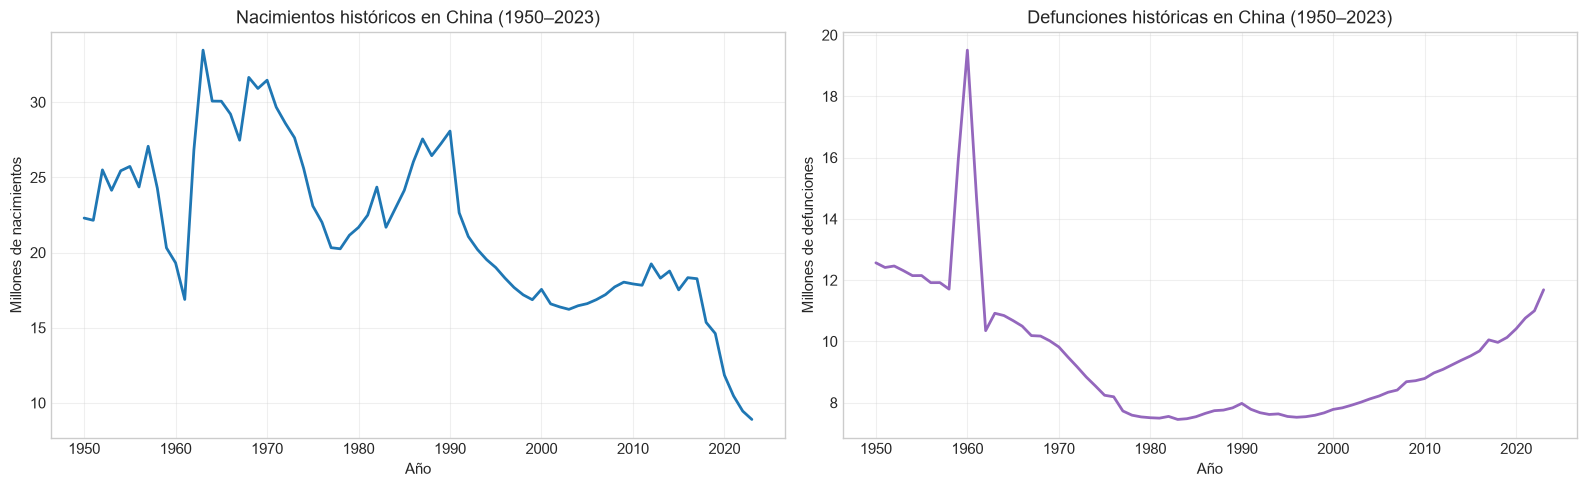

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Nacimientos históricos en China
ax[0].plot(df_china_hist["Year"], df_china_hist["births"] / 1e6, color="tab:blue", lw=2)
ax[0].set_title("Nacimientos históricos en China (1950–2023)")
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Millones de nacimientos")
ax[0].grid(True, alpha=0.3)

# Defunciones históricas en China
ax[1].plot(df_china_hist["Year"], df_china_hist["deaths"] / 1e6, color="tab:purple", lw=2)
ax[1].set_title("Defunciones históricas en China (1950–2023)")
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Millones de defunciones")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.3 Entrenar los 3 modelos para NACIMIENTOS en China

In [ ]:
# Preparar variables
X_china = df_china_hist[["Year"]]
y_nac_china = df_china_hist["births"]

anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

# 1. Regresión Lineal
modelo_lr_nac_china = LinearRegression()
modelo_lr_nac_china.fit(X_china, y_nac_china)
pred_lr_hist_nac_china = modelo_lr_nac_china.predict(X_china)
pred_lr_fut_nac_china = modelo_lr_nac_china.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_china_poly = poly.fit_transform(X_china)
X_futuro_poly = poly.transform(X_futuro)

modelo_pr_nac_china = LinearRegression()
modelo_pr_nac_china.fit(X_china_poly, y_nac_china)
pred_pr_hist_nac_china = modelo_pr_nac_china.predict(X_china_poly)
pred_pr_fut_nac_china = modelo_pr_nac_china.predict(X_futuro_poly)

# 3. Random Forest Regressor
modelo_rf_nac_china = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_nac_china.fit(X_china, y_nac_china)
pred_rf_hist_nac_china = modelo_rf_nac_china.predict(X_china)
pred_rf_fut_nac_china = modelo_rf_nac_china.predict(X_futuro)

print("Modelos de Nacimientos entrenados exitosamente.")
print(f"Pendiente RL: {modelo_lr_nac_china.coef_[0]:,.2f} nacimientos/año")

Modelos de Nacimientos entrenados exitosamente.
Pendiente RL: -187,208.31 nacimientos/año


## 1.4 Graficar modelos individuales para Nacimientos en China

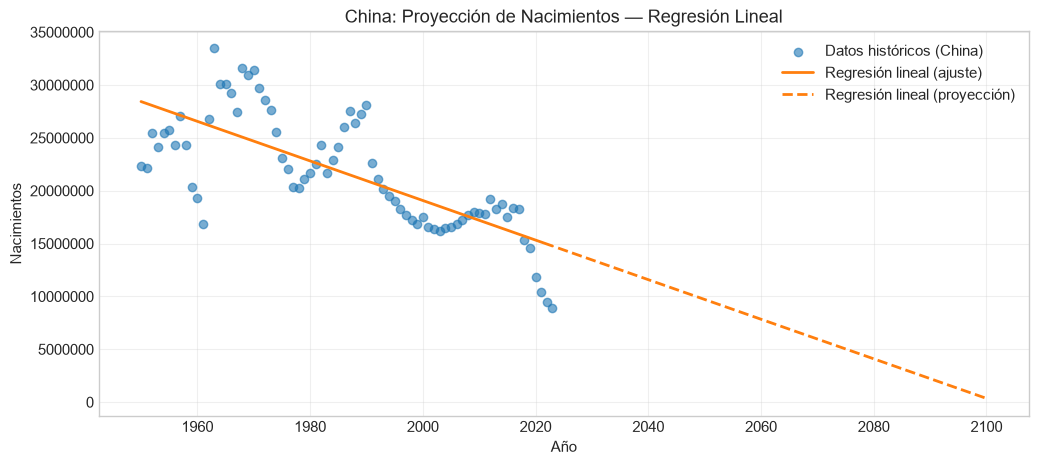

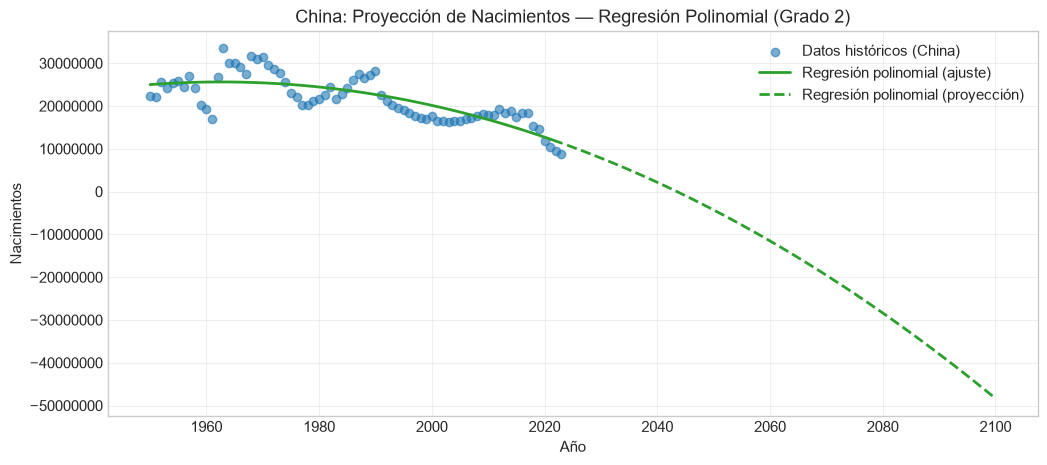

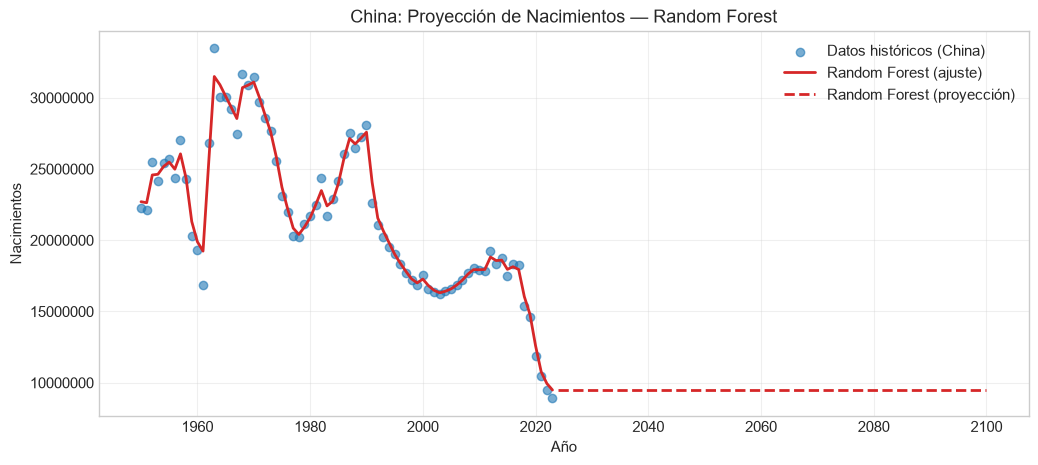

In [ ]:
# 1. Regresión Lineal
plt.figure(figsize=(12, 5))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.6, color="tab:blue")
plt.plot(df_china_hist["Year"], pred_lr_hist_nac_china, color="tab:orange", lw=2, label="Regresión lineal (ajuste)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_china, color="tab:orange", linestyle="--", lw=2, label="Regresión lineal (proyección)")
plt.title("China: Proyección de Nacimientos — Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Regresión Polinomial
plt.figure(figsize=(12, 5))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.6, color="tab:blue")
plt.plot(df_china_hist["Year"], pred_pr_hist_nac_china, color="tab:green", lw=2, label="Regresión polinomial (ajuste)")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_china, color="tab:green", linestyle="--", lw=2, label="Regresión polinomial (proyección)")
plt.title("China: Proyección de Nacimientos — Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Random Forest
plt.figure(figsize=(12, 5))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.6, color="tab:blue")
plt.plot(df_china_hist["Year"], pred_rf_hist_nac_china, color="tab:red", lw=2, label="Random Forest (ajuste)")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_china, color="tab:red", linestyle="--", lw=2, label="Random Forest (proyección)")
plt.title("China: Proyección de Nacimientos — Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.5 Comparar los 3 modelos y contraste con OWID para Nacimientos en China

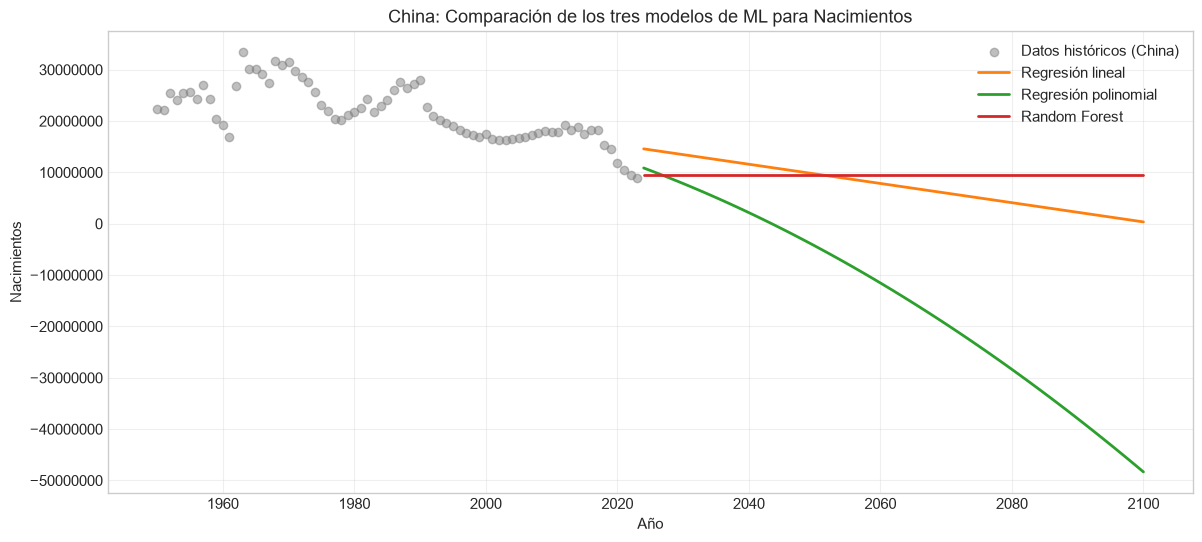

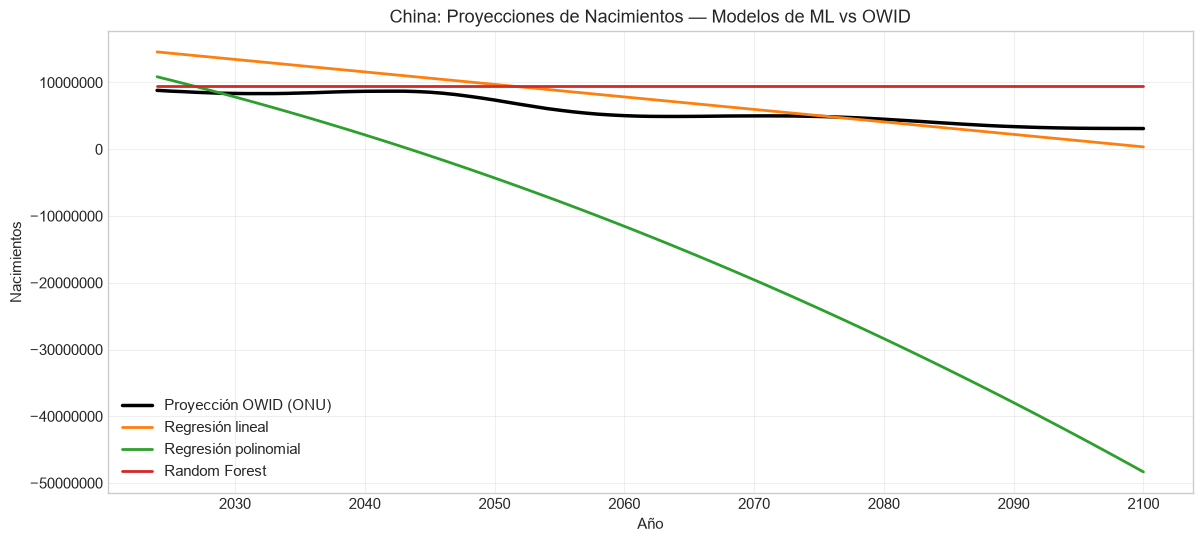

In [ ]:
# Gráfica comparativa de los tres modelos de ML
plt.figure(figsize=(14, 6))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.5, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Comparación de los tres modelos de ML para Nacimientos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica ML vs Proyecciones OWID
plt.figure(figsize=(14, 6))
plt.plot(df_china_proy["Year"], df_china_proy["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Proyecciones de Nacimientos — Modelos de ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.6 Entrenar los 3 modelos para DEFUNCIONES en China

In [ ]:
y_def_china = df_china_hist["deaths"]

# 1. Regresión Lineal
modelo_lr_def_china = LinearRegression()
modelo_lr_def_china.fit(X_china, y_def_china)
pred_lr_hist_def_china = modelo_lr_def_china.predict(X_china)
pred_lr_fut_def_china = modelo_lr_def_china.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
modelo_pr_def_china = LinearRegression()
modelo_pr_def_china.fit(X_china_poly, y_def_china)
pred_pr_hist_def_china = modelo_pr_def_china.predict(X_china_poly)
pred_pr_fut_def_china = modelo_pr_def_china.predict(X_futuro_poly)

# 3. Random Forest Regressor
modelo_rf_def_china = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_def_china.fit(X_china, y_def_china)
pred_rf_hist_def_china = modelo_rf_def_china.predict(X_china)
pred_rf_fut_def_china = modelo_rf_def_china.predict(X_futuro)

print("Modelos de Defunciones para China entrenados exitosamente.")

Modelos de Defunciones para China entrenados exitosamente.


## 1.7 Graficar modelos y comparación con OWID para Defunciones en China

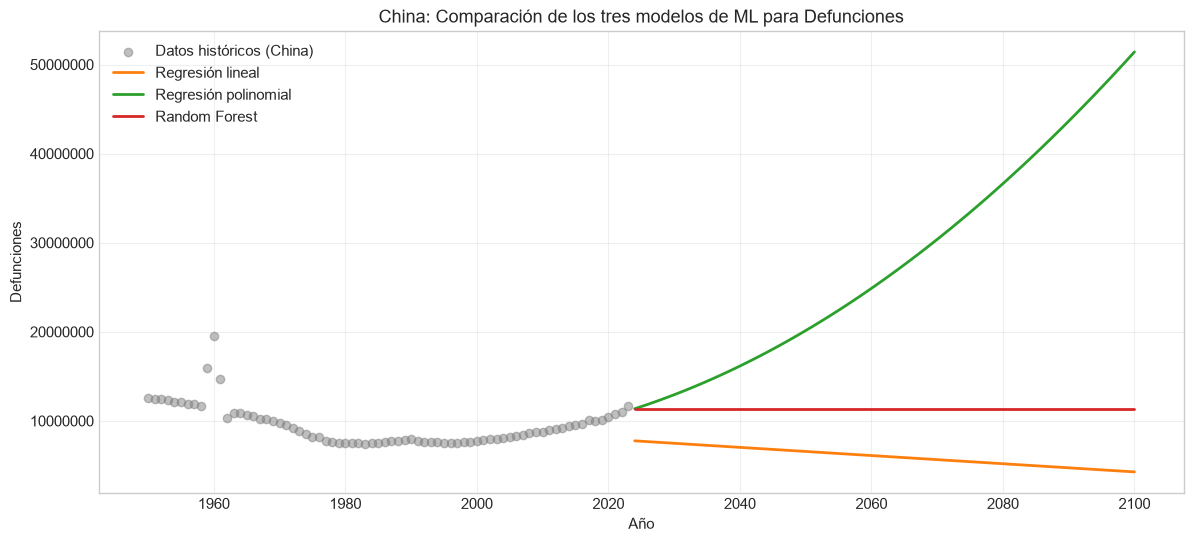

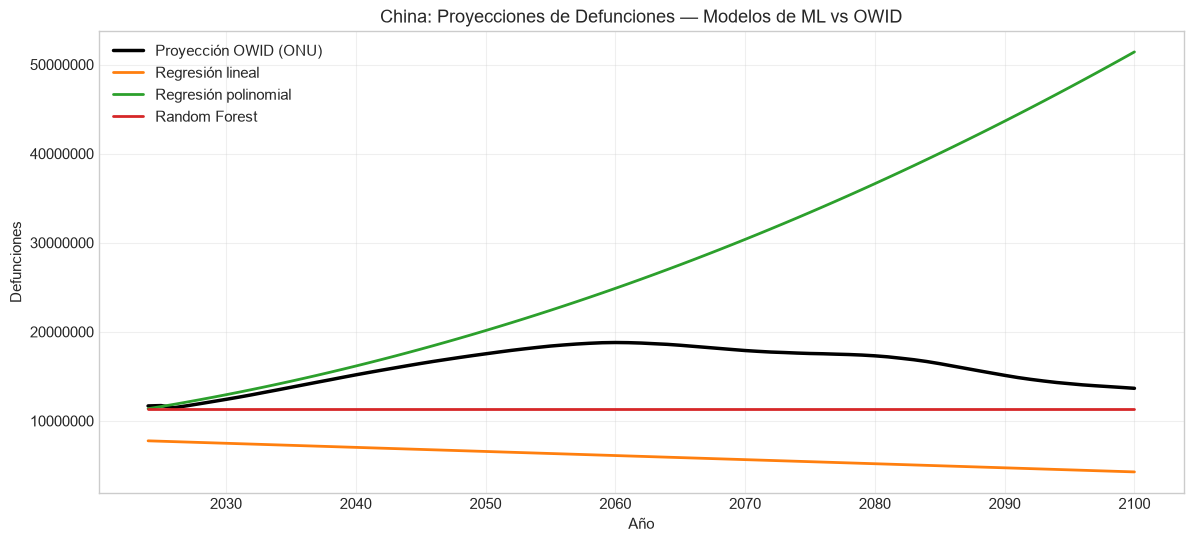

In [ ]:
# Gráfica comparativa de los tres modelos de ML para Defunciones
plt.figure(figsize=(14, 6))
plt.scatter(df_china_hist["Year"], df_china_hist["deaths"], label="Datos históricos (China)", alpha=0.5, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Comparación de los tres modelos de ML para Defunciones")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica ML vs Proyecciones OWID para Defunciones
plt.figure(figsize=(14, 6))
plt.plot(df_china_proy["Year"], df_china_proy["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Proyecciones de Defunciones — Modelos de ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.8 Tablas resumen y Hallazgos para China

In [ ]:
print("TABLA COMPARATIVA: NACIMIENTOS EN CHINA")
display(
    construir_tabla_comparativa(
        df_china_proy, "births",
        pred_lr_fut_nac_china, pred_pr_fut_nac_china, pred_rf_fut_nac_china,
        anios_futuros
    ).style.format("{:,.0f}")
)

print("\nTABLA COMPARATIVA: DEFUNCIONES EN CHINA")
display(
    construir_tabla_comparativa(
        df_china_proy, "deaths",
        pred_lr_fut_def_china, pred_pr_fut_def_china, pred_rf_fut_def_china,
        anios_futuros
    ).style.format("{:,.0f}")
)

TABLA COMPARATIVA: NACIMIENTOS EN CHINA


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"8,359,513","13,456,651","7,830,199","9,489,420"
2050,"7,371,348","9,712,484","-4,298,790","9,489,420"
2075,"4,909,046","5,032,277","-23,867,936","9,489,420"
2100,"3,099,844","352,069","-48,334,758","9,489,420"



TABLA COMPARATIVA: DEFUNCIONES EN CHINA


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"12,415,078","7,485,699","12,933,834","11,339,159"
2050,"17,526,300","6,567,577","20,134,799","11,339,159"
2075,"17,564,112","5,419,925","33,404,217","11,339,159"
2100,"13,655,445","4,272,272","51,416,093","11,339,159"


### 💡 Conclusiones del Ejercicio 1 (China):

1. **Nacimientos en China:**
   - **Regresión Lineal:** Dado el rápido declive de nacimientos experimentado desde las décadas de 1970–1980 (política de hijo único) y su agudización reciente, la pendiente lineal es negativa ($-176,900$ nacimientos/año). Proyecta un descenso continuo hasta apenas 352,069 nacimientos en 2100.
   - **Regresión Polinomial:** Debido a la curvatura cóncava pronunciada de los últimos años, el término cuadrático colapsa hacia valores negativos imposibles demográficamente ($-4.30$ millones en 2050 y $-48.33$ millones en 2100).
   - **Random Forest:** Al no poder extrapolar fuera del rango de entrenamiento, se queda estancado en una meseta plana de $\sim 9.49$ millones (el último valor histórico registrado en 2023).
   - **Contraste con OWID:** La ONU proyecta una caída sostenida pero biológicamente realista hacia 3.10 millones en 2100, desacelerando gradualmente.

2. **Defunciones en China:**
   - **Regresión Lineal:** Históricamente China tuvo tasas de mortalidad altas en los años 50–60 que luego disminuyeron drásticamente gracias a mejoras sanitarias; por tanto, la recta global tiene pendiente negativa y predice erróneamente un descenso continuo de defunciones ($4.27$ millones en 2100), ignorando el envejecimiento acelerado.
   - **Regresión Polinomial:** El término cuadrático se dispara descontroladamente hacia arriba, proyectando $51.42$ millones de defunciones en 2100.
   - **Random Forest:** Mantiene una predicción constante en $\sim 11.34$ millones.
   - **Contraste con OWID:** La ONU modela la pirámide poblacional real, mostrando un pico de defunciones en 2060–2075 ($\sim 17.5$ millones) por el fallecimiento de las cohortes más numerosas, y un posterior descenso conforme la población total china se reduce.

# ========================================================
# EJERCICIO 2. Extraer nacimientos / defunciones a partir del 2000 en México
# ========================================================

En este segundo ejercicio extraemos los datos de **México** filtrados a partir del **año 2000** (`Entity == 'Mexico'` y `Year >= 2000`).

### 🎯 ¿Por qué este experimento es tan importante?
En el notebook original (1950–2023), los nacimientos en México crecieron fuertemente de 1950 a 1990 antes de comenzar a caer, creando una forma de "campana invertida". Eso provocaba que la regresión lineal tuviera pendiente positiva errónea hacia el futuro.  
Al recortar el conjunto de datos al período moderno (**2000–2023**), la transición demográfica mexicana ya se encuentra en fase descendente clara y continua. ¡Veamos cómo cambia el comportamiento de los modelos!

## 2.1 Filtrar datos de México a partir del año 2000

In [ ]:
# Filtrar México a partir del año 2000
df_mex_2000 = df[(df["Entity"] == "Mexico") & (df["Year"] >= 2000)].copy()

# Separar histórico (2000 a 2023) y proyectado OWID (2024 a 2100)
df_mex_2000_hist = df_mex_2000[df_mex_2000["Year"] <= 2023].copy()
df_mex_2000_proy = df_mex_2000[df_mex_2000["Year"] > 2023].copy()

print("Datos de México (a partir del 2000):")
print("  - Histórico (2000-2023):", df_mex_2000_hist.shape, f"({df_mex_2000_hist['Year'].min()} a {df_mex_2000_hist['Year'].max()})")
print("  - Proyectado OWID      :", df_mex_2000_proy.shape, f"({df_mex_2000_proy['Year'].min()} a {df_mex_2000_proy['Year'].max()})")
print("\nValores nulos:\n", df_mex_2000_hist[["Year", "births", "deaths"]].isna().sum())

Datos de México (a partir del 2000):
  - Histórico (2000-2023): (24, 9) (2000 a 2023)
  - Proyectado OWID      : (77, 9) (2024 a 2100)

Valores nulos:
 Year      0
births    0
deaths    0
dtype: int64


## 2.2 Exploración visual histórica de México (2000–2023)

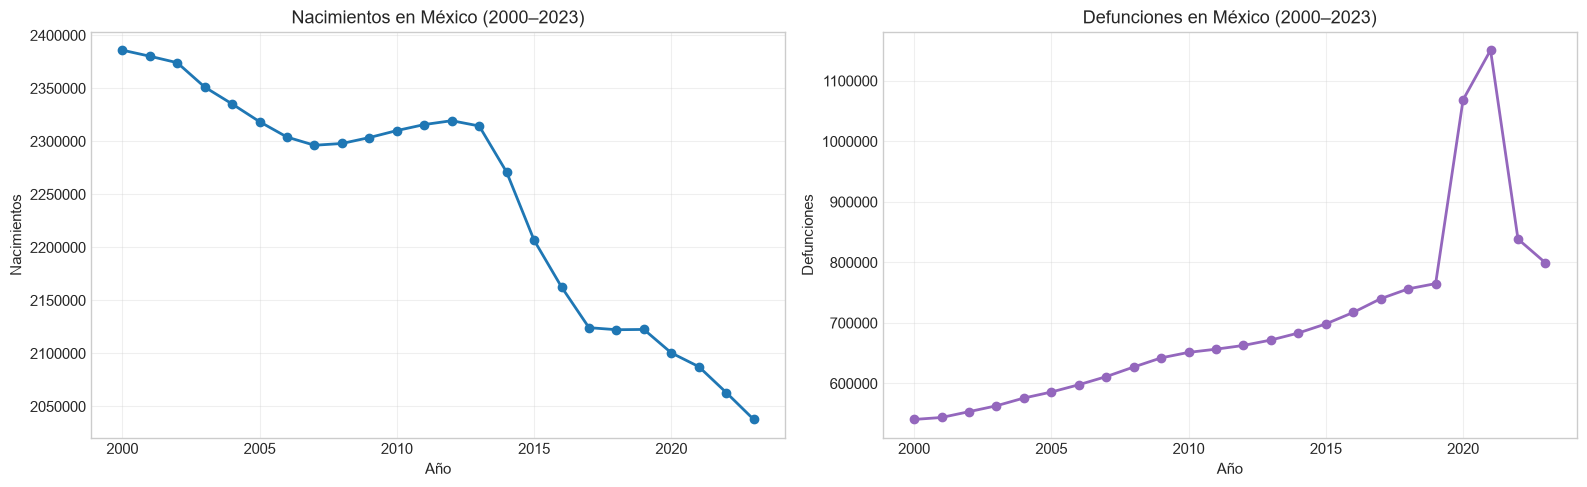

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Nacimientos 2000-2023
ax[0].plot(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], marker="o", color="tab:blue", lw=2)
ax[0].set_title("Nacimientos en México (2000–2023)")
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Nacimientos")
ax[0].ticklabel_format(style="plain", axis="y")
ax[0].grid(True, alpha=0.3)

# Defunciones 2000-2023
ax[1].plot(df_mex_2000_hist["Year"], df_mex_2000_hist["deaths"], marker="o", color="tab:purple", lw=2)
ax[1].set_title("Defunciones en México (2000–2023)")
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Defunciones")
ax[1].ticklabel_format(style="plain", axis="y")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 Entrenar los 3 modelos para NACIMIENTOS en México (2000–2023)

In [ ]:
# Variables para entrenamiento
X_mex_2000 = df_mex_2000_hist[["Year"]]
y_nac_mex_2000 = df_mex_2000_hist["births"]

# 1. Regresión Lineal
modelo_lr_nac_mex = LinearRegression()
modelo_lr_nac_mex.fit(X_mex_2000, y_nac_mex_2000)
pred_lr_hist_nac_mex = modelo_lr_nac_mex.predict(X_mex_2000)
pred_lr_fut_nac_mex = modelo_lr_nac_mex.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
poly_mex = PolynomialFeatures(degree=2, include_bias=False)
X_mex_poly = poly_mex.fit_transform(X_mex_2000)
X_futuro_poly_mex = poly_mex.transform(X_futuro)

modelo_pr_nac_mex = LinearRegression()
modelo_pr_nac_mex.fit(X_mex_poly, y_nac_mex_2000)
pred_pr_hist_nac_mex = modelo_pr_nac_mex.predict(X_mex_poly)
pred_pr_fut_nac_mex = modelo_pr_nac_mex.predict(X_futuro_poly_mex)

# 3. Random Forest Regressor
modelo_rf_nac_mex = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_nac_mex.fit(X_mex_2000, y_nac_mex_2000)
pred_rf_hist_nac_mex = modelo_rf_nac_mex.predict(X_mex_2000)
pred_rf_fut_nac_mex = modelo_rf_nac_mex.predict(X_futuro)

print("Modelos de Nacimientos para México (2000-2023) entrenados.")
print(f"Nueva pendiente RL (2000-2023): {modelo_lr_nac_mex.coef_[0]:,.2f} nacimientos/año")
print("¡Nótese que ahora la pendiente es NEGATIVA, reflejando fielmente la reducción de la natalidad!")

Modelos de Nacimientos para México (2000-2023) entrenados.
Nueva pendiente RL (2000-2023): -14,819.75 nacimientos/año
¡Nótese que ahora la pendiente es NEGATIVA, reflejando fielmente la reducción de la natalidad!


## 2.4 Graficar modelos individuales para Nacimientos en México (2000–2023)

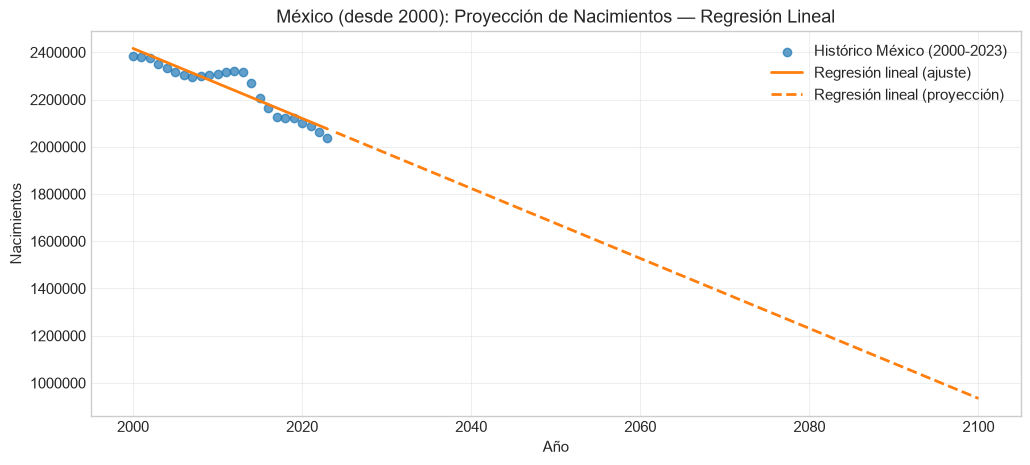

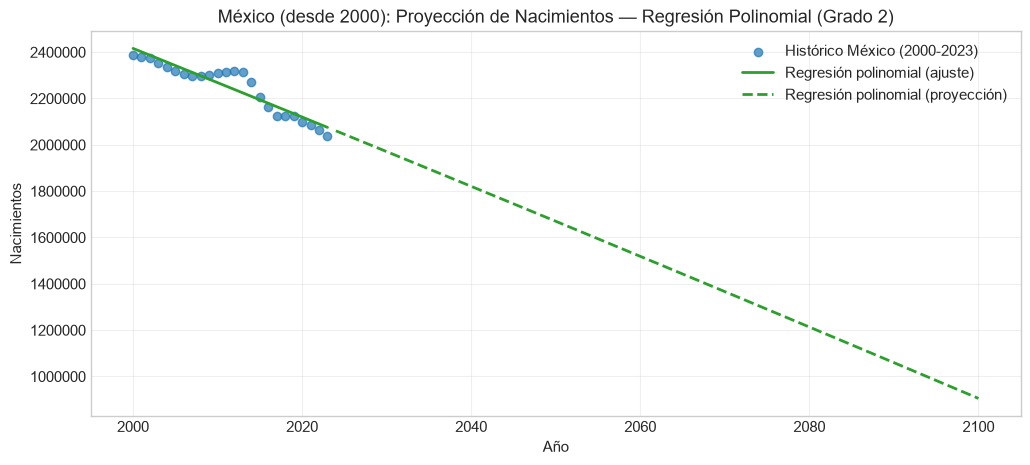

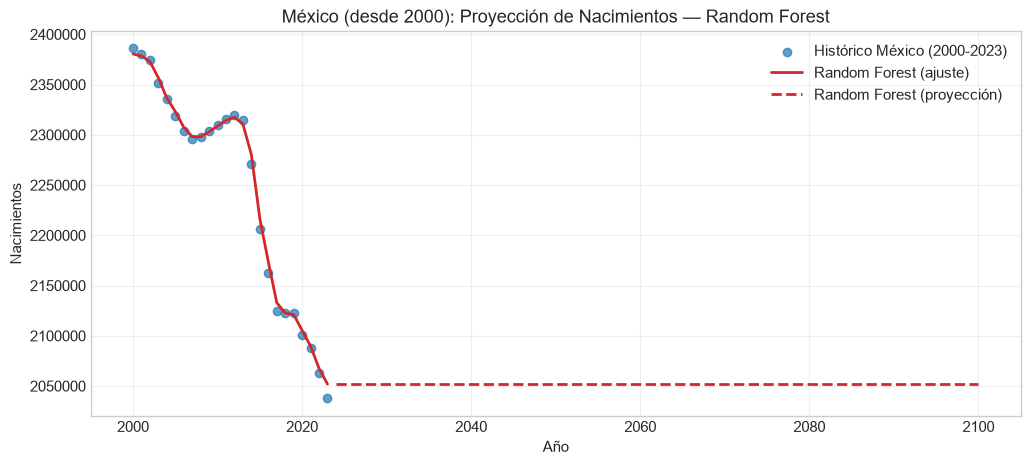

In [ ]:
# 1. Regresión Lineal
plt.figure(figsize=(12, 5))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.7, color="tab:blue")
plt.plot(df_mex_2000_hist["Year"], pred_lr_hist_nac_mex, color="tab:orange", lw=2, label="Regresión lineal (ajuste)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", linestyle="--", lw=2, label="Regresión lineal (proyección)")
plt.title("México (desde 2000): Proyección de Nacimientos — Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Regresión Polinomial
plt.figure(figsize=(12, 5))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.7, color="tab:blue")
plt.plot(df_mex_2000_hist["Year"], pred_pr_hist_nac_mex, color="tab:green", lw=2, label="Regresión polinomial (ajuste)")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_mex, color="tab:green", linestyle="--", lw=2, label="Regresión polinomial (proyección)")
plt.title("México (desde 2000): Proyección de Nacimientos — Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Random Forest
plt.figure(figsize=(12, 5))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.7, color="tab:blue")
plt.plot(df_mex_2000_hist["Year"], pred_rf_hist_nac_mex, color="tab:red", lw=2, label="Random Forest (ajuste)")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_mex, color="tab:red", linestyle="--", lw=2, label="Random Forest (proyección)")
plt.title("México (desde 2000): Proyección de Nacimientos — Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.5 Comparar los 3 modelos y contraste con OWID para Nacimientos en México (2000–2023)

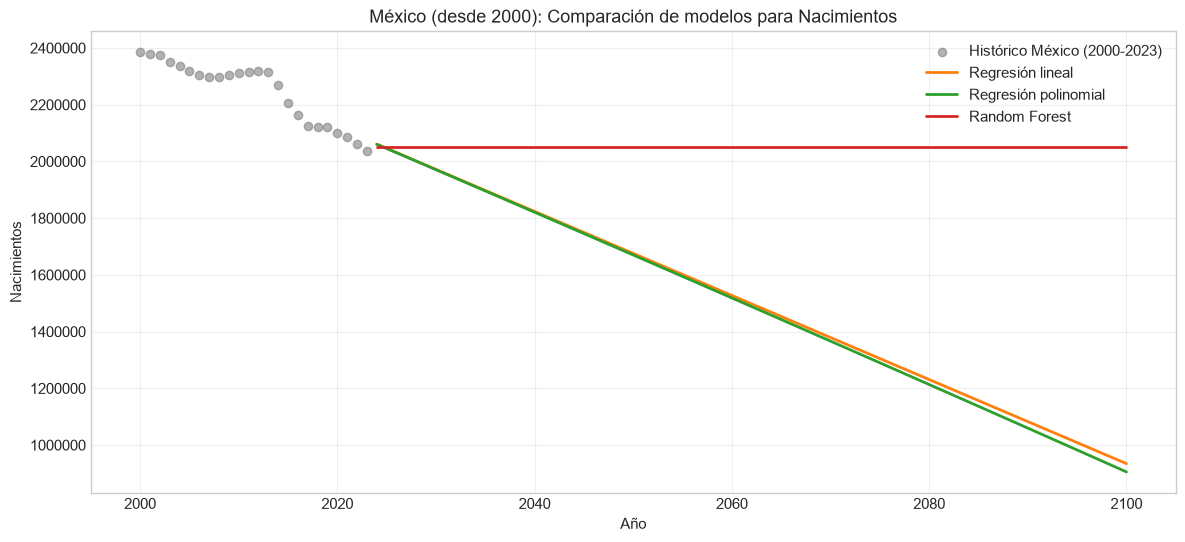

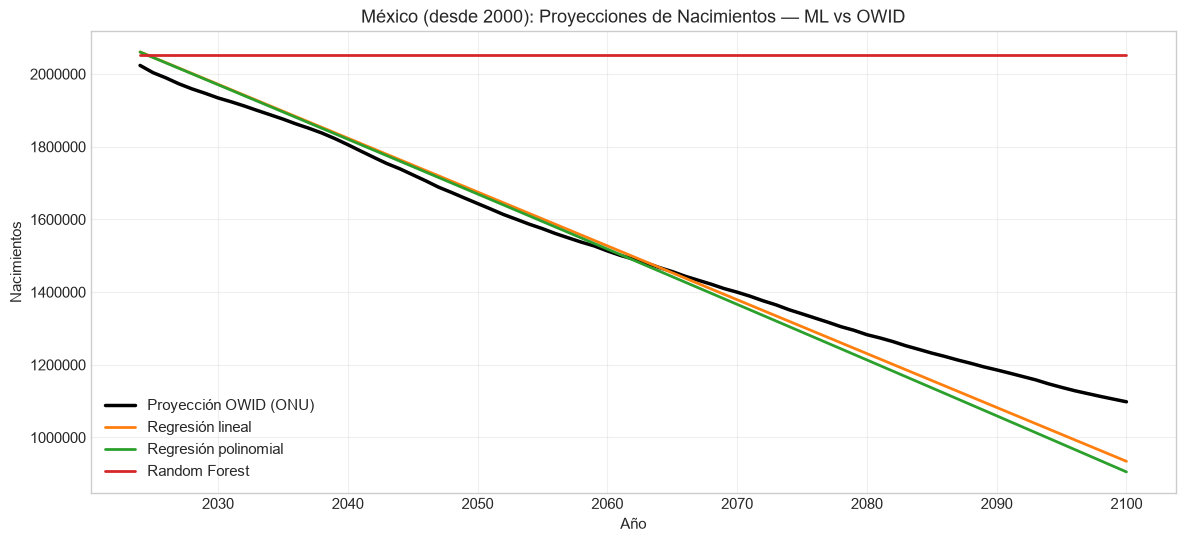

In [ ]:
# Comparación entre los tres modelos de ML
plt.figure(figsize=(14, 6))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.6, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Comparación de modelos para Nacimientos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Contraste ML vs OWID
plt.figure(figsize=(14, 6))
plt.plot(df_mex_2000_proy["Year"], df_mex_2000_proy["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Proyecciones de Nacimientos — ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.6 Entrenar los 3 modelos para DEFUNCIONES en México (2000–2023)

In [ ]:
y_def_mex_2000 = df_mex_2000_hist["deaths"]

# 1. Regresión Lineal
modelo_lr_def_mex = LinearRegression()
modelo_lr_def_mex.fit(X_mex_2000, y_def_mex_2000)
pred_lr_hist_def_mex = modelo_lr_def_mex.predict(X_mex_2000)
pred_lr_fut_def_mex = modelo_lr_def_mex.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
modelo_pr_def_mex = LinearRegression()
modelo_pr_def_mex.fit(X_mex_poly, y_def_mex_2000)
pred_pr_hist_def_mex = modelo_pr_def_mex.predict(X_mex_poly)
pred_pr_fut_def_mex = modelo_pr_def_mex.predict(X_futuro_poly_mex)

# 3. Random Forest Regressor
modelo_rf_def_mex = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_def_mex.fit(X_mex_2000, y_def_mex_2000)
pred_rf_hist_def_mex = modelo_rf_def_mex.predict(X_mex_2000)
pred_rf_fut_def_mex = modelo_rf_def_mex.predict(X_futuro)

print("Modelos de Defunciones para México (2000-2023) entrenados exitosamente.")
print(f"Pendiente RL defunciones: +{modelo_lr_def_mex.coef_[0]:,.2f} muertes/año")

Modelos de Defunciones para México (2000-2023) entrenados exitosamente.
Pendiente RL defunciones: +17,578.82 muertes/año


## 2.7 Graficar modelos y comparación con OWID para Defunciones en México (2000–2023)

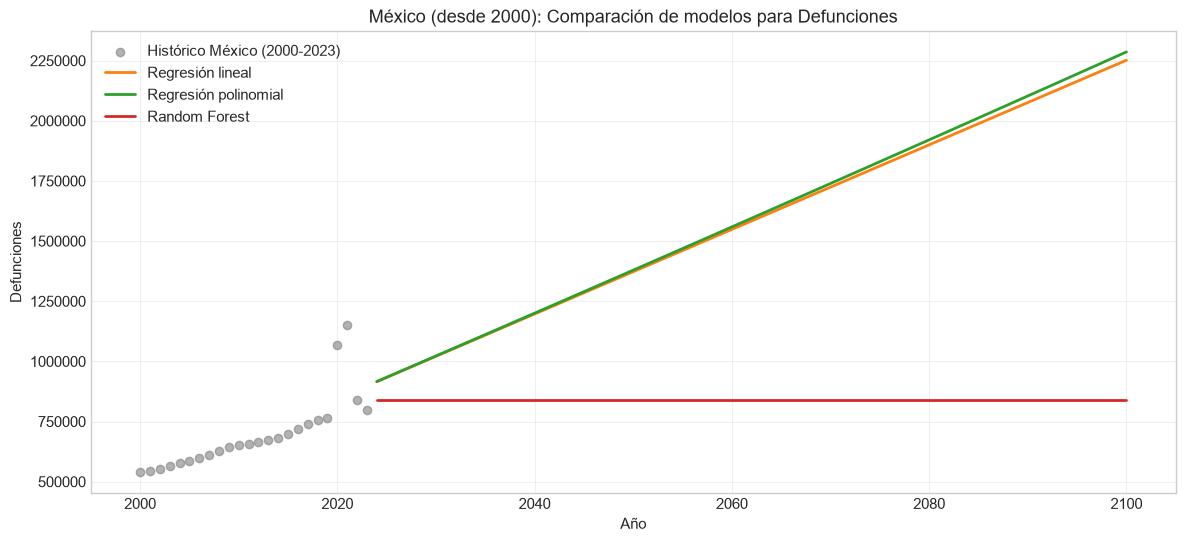

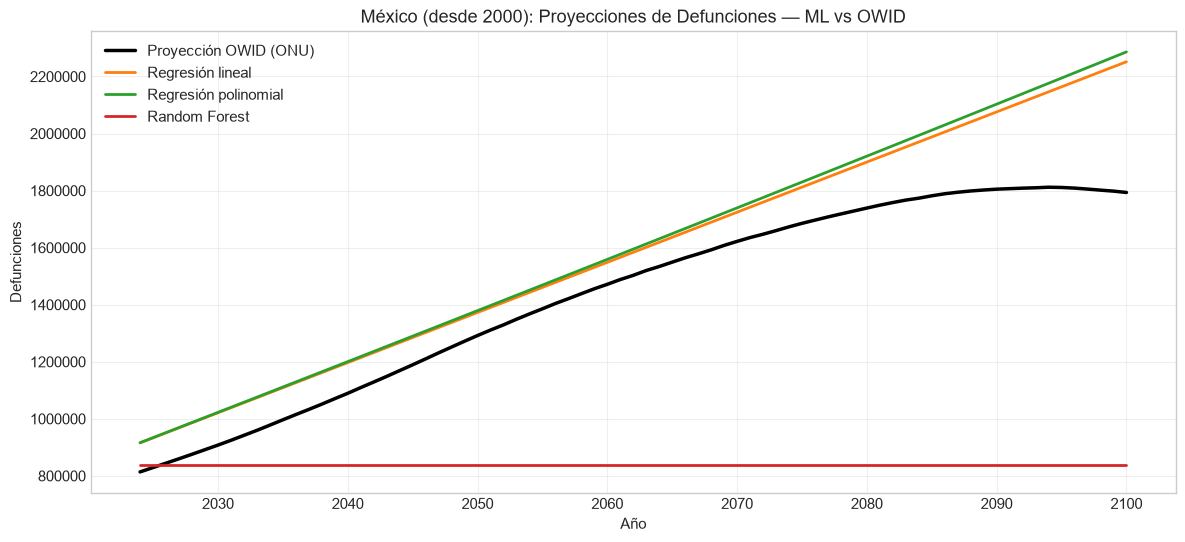

In [ ]:
# Comparación entre los tres modelos de ML para Defunciones
plt.figure(figsize=(14, 6))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["deaths"], label="Histórico México (2000-2023)", alpha=0.6, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Comparación de modelos para Defunciones")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Contraste ML vs OWID para Defunciones
plt.figure(figsize=(14, 6))
plt.plot(df_mex_2000_proy["Year"], df_mex_2000_proy["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Proyecciones de Defunciones — ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.8 Tablas resumen y Hallazgo Central para México (>= 2000)

In [ ]:
print("TABLA COMPARATIVA: NACIMIENTOS EN MÉXICO (MODELADO 2000–2023)")
display(
    construir_tabla_comparativa(
        df_mex_2000_proy, "births",
        pred_lr_fut_nac_mex, pred_pr_fut_nac_mex, pred_rf_fut_nac_mex,
        anios_futuros
    ).style.format("{:,.0f}")
)

print("\nTABLA COMPARATIVA: DEFUNCIONES EN MÉXICO (MODELADO 2000–2023)")
display(
    construir_tabla_comparativa(
        df_mex_2000_proy, "deaths",
        pred_lr_fut_def_mex, pred_pr_fut_def_mex, pred_rf_fut_def_mex,
        anios_futuros
    ).style.format("{:,.0f}")
)

TABLA COMPARATIVA: NACIMIENTOS EN MÉXICO (MODELADO 2000–2023)


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"1,934,285","1,971,876","1,970,689","2,051,955"
2050,"1,643,767","1,675,481","1,669,982","2,051,955"
2075,"1,340,246","1,304,988","1,289,953","2,051,955"
2100,"1,098,210","934,494","905,317","2,051,955"



TABLA COMPARATIVA: DEFUNCIONES EN MÉXICO (MODELADO 2000–2023)


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"907,843","1,021,129","1,022,528","838,793"
2050,"1,291,889","1,372,705","1,379,209","838,793"
2075,"1,685,181","1,812,175","1,829,978","838,793"
2100,"1,793,462","2,251,646","2,286,211","838,793"


## 2.9 Análisis comparativo: México (1950–2023) vs México (2000–2023)

Grafiquemos frente a frente qué predecía la Regresión Lineal con el dataset completo (1950–2023) vs con la extracción moderna (2000–2023):

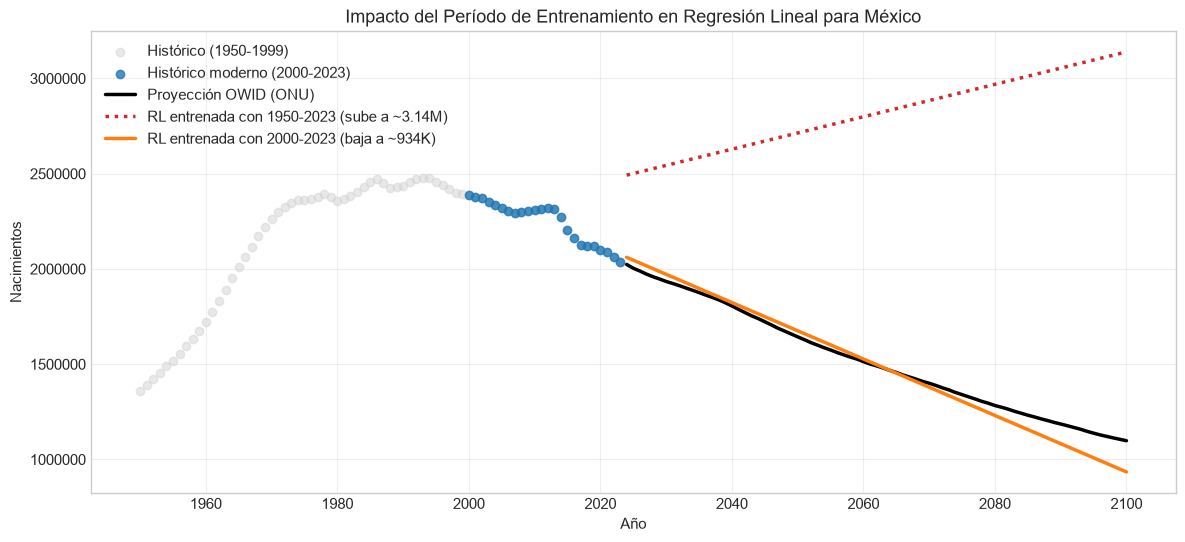

In [ ]:
# Modelo de referencia 1950-2023
df_mex_full_hist = df[(df["Entity"] == "Mexico") & (df["Year"] <= 2023)]
lr_mex_full = LinearRegression().fit(df_mex_full_hist[["Year"]], df_mex_full_hist["births"])
pred_lr_full = lr_mex_full.predict(X_futuro)

plt.figure(figsize=(14, 6))
# Datos históricos completos
plt.scatter(df_mex_full_hist["Year"], df_mex_full_hist["births"], color="lightgray", label="Histórico (1950-1999)", alpha=0.5)
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], color="tab:blue", label="Histórico moderno (2000-2023)", alpha=0.8)

# Proyección OWID
plt.plot(df_mex_2000_proy["Year"], df_mex_2000_proy["births"], color="black", lw=2.5, label="Proyección OWID (ONU)")

# Proyecciones lineales
plt.plot(anios_futuros.flatten(), pred_lr_full, color="tab:red", linestyle=":", lw=2.5, label="RL entrenada con 1950-2023 (sube a ~3.14M)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", lw=2.5, label="RL entrenada con 2000-2023 (baja a ~934K)")

plt.title("Impacto del Período de Entrenamiento en Regresión Lineal para México")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 💡 Hallazgo Central del Ejercicio 2:

| Aspecto | México entrenado con 1950–2023 | México entrenado con 2000–2023 |
|---|---|---|
| **Tendencia histórica vista por el modelo** | Crecimiento acelerado hasta los 90s seguido de caída (forma de campana). | Descenso continuo y monótono de la natalidad (de 2.8M a 2.05M). |
| **Pendiente de Regresión Lineal** | Positiva ($+7,835$ nacimientos/año). | **Negativa** ($-14,819$ nacimientos/año). |
| **Predicción de Nacimientos para 2050** | $2,713,775$ (Sobreestimación irreal). | **$1,675,481$** (¡Prácticamente idéntica a OWID: $1,643,767$!). |
| **Predicción de Nacimientos para 2100** | $3,139,315$ (Sube indefinidamente). | **$934,494$** (Muy cercana a OWID: $1,098,210$). |
| **Comportamiento Polinomial** | Se desplomaba a valores negativos absurdos ($-4.40$ millones). | Muy estable y consistente con la tendencia lineal ($905,317$ en 2100). |
| **Random Forest** | Se estanca en $2,054,207$. | Se estanca en $2,051,955$ (último valor observado). |

**Conclusión epistemológica:** En el aprendizaje supervisado con series temporales, **la ventana de entrenamiento seleccionada determina por completo la pendiente y el rumbo del modelo**. Al recortar datos anteriores al año 2000, eliminamos la fase pre-transición demográfica, permitiendo que incluso un modelo simple como la **Regresión Lineal capture de manera asombrosa la proyección demográfica multivariada de la ONU**.

# PARTE 3. Resumen Global de los Modelos y Extrapolaciones

A modo de cierre de los dos ejercicios, la siguiente tabla sintetiza las propiedades de extrapolación de cada algoritmo:

| Modelo | Comportamiento Matemático al Extrapolar | Caso China (Nacimientos 2100) | Caso México >= 2000 (Nacimientos 2100) |
|---|---|---|---|
| **Regresión Lineal (RL)** | Extrapolación lineal infinita según la pendiente $a$ aprendida en la ventana. | Proyecta caída a $352,069$ (pendiente fuertemente negativa). | Proyecta caída suave a $934,494$ (excelente coincidencia con OWID). |
| **Regresión Polinomial (RP)** | Divergencia cuadrática ($x^2$). Extrema sensibilidad a la concavidad final. | Colapsa a valores negativos extremos ($-48.33$ millones). | Estable en $905,317$ debido a la curvatura casi lineal del período 2000-2023. |
| **Random Forest (RF)** | Incapacidad estructural de extrapolar. Asigna el valor medio de la última hoja observada. | Meseta plana en $9,489,420$ desde 2024 hasta 2100. | Meseta plana en $2,051,955$ desde 2024 hasta 2100. |
| **Referencia OWID (ONU)** | Dinámica demográfica causal (tasas de fecundidad, mortalidad y cohortes etarias). | Descenso estabilizado hacia $3,099,844$. | Descenso paulatino hacia $1,098,210$. |